#Lab 3
##Data Preprocessing & Feature Engineering
###Kamar Bdair - S23108164
CS4082-1
Dr. Naila

###Part 1: Understanding the Problem with Messy Data
####Step1.1: Messy Dataset

In [54]:
from numpy.random import choice
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200
data = {"age": np.random.randint(18, 80, n).astype(float),
        "blood_pressure": np.round(np.random.uniform(90, 180, n), 1),
        "cholesterol": np.round(np.random.uniform(150, 350, n), 1),
        "bmi": np.round(np.random.uniform(18, 42, n), 1),
        "gender":np.random.choice(["Male", "Female"], n),
        "city": np.random.choice(["Jeddah", "Riyadh", "Dammam", "Makkah"], n),
        "smoker": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
        "heart_disease": np.random.choice([0, 1], n, p=[0.6, 0.4])}

df = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:15], "blood_pressure"] = np.nan
df.loc[missing_idx[15:], "cholesterol"] = np.nan

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows: ")
print(df.head())
print(f"\nMissing values per column: ")
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows: 
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column: 
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


####Step1.2: Identifing Issues

In [28]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Numeric Ranges ===")
print(df.describe().round(2))

print("\n=== Categorical Columns ===")
for col in ["gender", "city", "smoker"]:
  print(f"{col}: {df[col].unique()}")

=== Data Types ===
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values ===
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges ===
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75       301.95   34.67           1.00
ma

In [29]:
print("=== Before ===")
print(f"Original DataFrame shape: {df.shape}")

df = pd.get_dummies(df, columns=['gender', 'city', 'smoker'], drop_first=True)

print("\n=== After ===")
print(df.head())
print(f"New DataFrame shape: {df.shape}")

=== Before ===
Original DataFrame shape: (200, 8)

=== After ===
    age  blood_pressure  cholesterol   bmi  heart_disease  gender_Male  \
0  56.0           171.7        295.2  34.4              1         True   
1  69.0           112.4        345.2  21.9              0        False   
2  46.0           126.9        253.3  39.9              0        False   
3  32.0           158.0        214.6  37.7              1        False   
4  60.0           110.6        309.0  40.8              1         True   

   city_Jeddah  city_Makkah  city_Riyadh  smoker_Yes  
0        False        False         True       False  
1        False        False        False       False  
2         True        False        False       False  
3        False        False         True       False  
4        False         True        False        True  
New DataFrame shape: (200, 10)


In [30]:
print("\n=== Before Imputation (Missing Values) ===")
print(df[['age', 'blood_pressure', 'cholesterol']].isnull().sum())

# Impute missing 'age' values with the median and reassign
df['age'] = df['age'].fillna(df['age'].median())

# Impute missing 'blood_pressure' values with the median and reassign
df['blood_pressure'] = df['blood_pressure'].fillna(df['blood_pressure'].median())

# Impute missing 'cholesterol' values with the median and reassign
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print("\n=== After Imputation (Missing Values) ===")
print(df[['age', 'blood_pressure', 'cholesterol']].isnull().sum())


=== Before Imputation (Missing Values) ===
age               10
blood_pressure     5
cholesterol        5
dtype: int64

=== After Imputation (Missing Values) ===
age               0
blood_pressure    0
cholesterol       0
dtype: int64


#####Task1: Exploring mMessy Data

In [31]:
print("=== DataFrame Info ===")
df.info()

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             200 non-null    float64
 1   blood_pressure  200 non-null    float64
 2   cholesterol     200 non-null    float64
 3   bmi             200 non-null    float64
 4   heart_disease   200 non-null    int64  
 5   gender_Male     200 non-null    bool   
 6   city_Jeddah     200 non-null    bool   
 7   city_Makkah     200 non-null    bool   
 8   city_Riyadh     200 non-null    bool   
 9   smoker_Yes      200 non-null    bool   
dtypes: bool(5), float64(4), int64(1)
memory usage: 8.9 KB


In [32]:
print("\n=== Percentage of Missing Values ===")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

print("\n=== Column with the Most Missing Values ===")
most_missing_column = missing_percentage.idxmax()
print(f"The column with the most missing values is '{most_missing_column}' with {missing_percentage.max():.2f}% missing.")


=== Percentage of Missing Values ===
age               0.0
blood_pressure    0.0
cholesterol       0.0
bmi               0.0
heart_disease     0.0
gender_Male       0.0
city_Jeddah       0.0
city_Makkah       0.0
city_Riyadh       0.0
smoker_Yes        0.0
dtype: float64

=== Column with the Most Missing Values ===
The column with the most missing values is 'age' with 0.00% missing.


###Part 2: Handling Missing Values
####Step2.1: Impute Numeric Columns

In [53]:
df_median_imputed = df.copy()
numeric_cols = ["age", "blood_pressure", "cholesterol"]

median_values = df[numeric_cols].median()
print("Median values used for imputation:")
print(median_values)

for col in numeric_cols:
    df_median_imputed[col] = df_median_imputed[col].fillna(median_values[col])

print("\nMissing values in df_median_imputed after median imputation:")
print(df_median_imputed[numeric_cols].isnull().sum())

Median values used for imputation:
age                50.0
blood_pressure    138.2
cholesterol       255.5
dtype: float64

Missing values in df_median_imputed after median imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


####Step2.2: Verifing the Fix

In [36]:
print(f"Total messing values in entire dataset: {df.isnull().sum().sum()}")
print(f"\nDataset shape (no rows lost): {df.shape}")
print(df.describe().round(2))

Total messing values in entire dataset: 0

Dataset shape (no rows lost): (200, 10)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


#####Task2: Experiment with Imputation

In [55]:
df_mean_imputed = df.copy()
numeric_cols = ["age", "blood_pressure", "cholesterol"]

mean_values = df[numeric_cols].mean()
print("Mean values used for imputation:")
print(mean_values)

for col in numeric_cols:
    df_mean_imputed[col] = df_mean_imputed[col].fillna(mean_values[col])

print("\nMissing values in df_mean_imputed after mean imputation:")
print(df_mean_imputed[numeric_cols].isnull().sum())

Mean values used for imputation:
age                49.310526
blood_pressure    136.028205
cholesterol       252.280513
dtype: float64

Missing values in df_mean_imputed after mean imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


In [56]:
print("\n=== Comparing Imputed Values ===")

comparison_data = []

# Get original missing value indices for comparison
original_missing_age_indices = df[df['age'].isnull()].index
original_missing_blood_pressure_indices = df[df['blood_pressure'].isnull()].index
original_missing_cholesterol_indices = df[df['cholesterol'].isnull()].index

# Compare 'age' imputations
for idx in original_missing_age_indices:
    original_value = df.loc[idx, 'age']
    median_imputed_value = df_median_imputed.loc[idx, 'age']
    mean_imputed_value = df_mean_imputed.loc[idx, 'age']
    comparison_data.append({
        'Index': idx,
        'Column': 'age',
        'Original_Value': original_value,
        'Median_Imputed': median_imputed_value,
        'Mean_Imputed': mean_imputed_value
    })

# Compare 'blood_pressure' imputations
for idx in original_missing_blood_pressure_indices:
    original_value = df.loc[idx, 'blood_pressure']
    median_imputed_value = df_median_imputed.loc[idx, 'blood_pressure']
    mean_imputed_value = df_mean_imputed.loc[idx, 'blood_pressure']
    comparison_data.append({
        'Index': idx,
        'Column': 'blood_pressure',
        'Original_Value': original_value,
        'Median_Imputed': median_imputed_value,
        'Mean_Imputed': mean_imputed_value
    })

# Compare 'cholesterol' imputations
for idx in original_missing_cholesterol_indices:
    original_value = df.loc[idx, 'cholesterol']
    median_imputed_value = df_median_imputed.loc[idx, 'cholesterol']
    mean_imputed_value = df_mean_imputed.loc[idx, 'cholesterol']
    comparison_data.append({
        'Index': idx,
        'Column': 'cholesterol',
        'Original_Value': original_value,
        'Median_Imputed': median_imputed_value,
        'Mean_Imputed': mean_imputed_value
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string())



=== Comparing Imputed Values ===
    Index          Column  Original_Value  Median_Imputed  Mean_Imputed
0      18             age             NaN            50.0     49.310526
1      84             age             NaN            50.0     49.310526
2     112             age             NaN            50.0     49.310526
3     122             age             NaN            50.0     49.310526
4     142             age             NaN            50.0     49.310526
5     168             age             NaN            50.0     49.310526
6     178             age             NaN            50.0     49.310526
7     180             age             NaN            50.0     49.310526
8     184             age             NaN            50.0     49.310526
9     199             age             NaN            50.0     49.310526
10     33  blood_pressure             NaN           138.2    136.028205
11     51  blood_pressure             NaN           138.2    136.028205
12     76  blood_pressure     

Differences between mean and median imputation:

1.  Values Imputed:
    * Median Imputation: For 'age', the imputed value was `50.0`. For 'blood_pressure', it was `138.2`. For 'cholesterol', it was `255.5`. Median values are robust to outliers and represent the middle value in the dataset.
    *   Mean Imputation: For 'age', the imputed value was approximately `49.31`. For 'blood_pressure', it was approximately `136.03`. For 'cholesterol', it was approximately `252.28`. Mean values are influenced by all values in the dataset, including outliers, and tend to be more precise (floating-point numbers).

2.  Difference in Values: The imputed values for each column ('age', 'blood_pressure', 'cholesterol') are different between the mean and median methods. This is expected because the mean and median are generally different statistical measures, especially in datasets that are not perfectly symmetrical.

3.  Nature of Imputed Values:
    *   The median for 'age' (50.0) happened to be an integer (or a float with no decimal part), which might sometimes be more interpretable depending on the context if age is usually recorded as whole numbers. However, in this case, the original data `np.random.randint(18, 80, n).astype(float)` made `age` float, so the `50.0` is still a float.
    *   The mean values are generally floating-point numbers with more decimal places, reflecting the average of all observed values.


Conclusion:
Since the generated data is somewhat uniformly distributed, the differences between mean and median are not drastically large but are noticeable. If the distributions were heavily skewed or contained significant outliers, the difference would likely be more pronounced, and median imputation would generally be preferred for its robustness.

In [45]:
print("=== Before dropna ===")
print(f"Original DataFrame shape: {df.shape}")
print(f"Missing values before dropna:\n{df.isnull().sum()}")

df_after_dropna = df.dropna()
print("\n=== After dropna ===")
print(f"New DataFrame shape: {df_after_dropna.shape}")
print(f"Missing values after dropna:\n{df_after_dropna.isnull().sum()}")

rows_lost = df.shape[0] - df_after_dropna.shape[0]
print(f"\nNumber of rows lost: {rows_lost}")

=== Before dropna ===
Original DataFrame shape: (200, 8)
Missing values before dropna:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== After dropna ===
New DataFrame shape: (180, 8)
Missing values after dropna:
age               0
blood_pressure    0
cholesterol       0
bmi               0
gender            0
city              0
smoker            0
heart_disease     0
dtype: int64

Number of rows lost: 20


The output of dropna() 20 rows were lost, so our DataFrame went from (200, 8) down to (180, 8).

dropping rows (dropna()) might be a better approach than imputation for handling missing values:

1. Very Large Datasets with Minimal Missingness: If your dataset is extremely large and only a tiny fraction of rows have missing values, dropping those few rows might have a negligible impact on your analysis or model performance. The simplicity of dropna() can outweigh the complexity of imputation in such cases.
2. Missingness is Not At Random (MNAR) or Highly Informative: If the reason data is missing is itself informative and relates to the outcome you're trying to predict, and imputation might distort this relationship, dropping rows could be considered. For example, if patients with a severe condition are systematically less likely to have certain lab results, imputing those results might obscure the true signal.
3. Strict Data Integrity Requirements: In some applications, data integrity is paramount, and introducing 'artificial' values through imputation might not be acceptable. If only completely observed cases are to be used for regulatory, legal, or high-stakes applications, dropping rows ensures that all data points used are actual observations.
4. Feature Importance and Redundancy: If the column with missing values is not critically important to your analysis, or if its information is largely redundant with other, complete features, dropping rows might be a simple solution that doesn't compromise model performance significantly.
5. Computational Efficiency (Marginal Benefit): While imputation can be quick, for extremely large datasets and very few missing values, the overhead of running imputation algorithms might be slightly more than a simple dropna(), though this is rarely a primary driver for choosing dropna() over imputation.
Overall, dropna() is best used when can afford to lose data points without significantly impacting the analysis, typically in very large datasets with very few missing values, or when there's a strong reason not to introduce imputed values.

###Part 3: Encoding Categorical Variables
####Step3.1: Label Encoding for Binary Variables

In [57]:
from sklearn . preprocessing import LabelEncoder

le_gender = LabelEncoder()
df["gender_encoded"] = le_gender.fit_transform(df["gender"])

le_smoker = LabelEncoder()
df["smoker_encoded"] = le_smoker.fit_transform(df["smoker"])

print("Original vs Encoded: ")
print(df[["gender", "gender_encoded", "smoker", "smoker_encoded"]]. head (8) )

Original vs Encoded: 
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1
5  Female               0     No               0
6  Female               0     No               0
7  Female               0    Yes               1


####Step3.2: One-Hot Encoding for Multi-Category Variables

In [58]:
city_dummies = pd.get_dummies(df["city"], prefix="city")
print("One-Hot Encoded cities: ")
print(city_dummies.head())

df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=["gender", "city", "smoker"])

print(f"\nNew shape: {df.shape}")
print(f"\nNew columns: {list(df.columns)}")

One-Hot Encoded cities: 
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

New shape: (200, 11)

New columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


#####Task3: Practice Encoding

In [59]:
print("Fully encoded DataFrame (first 10 rows):")
display(df.head(10))
print(f"\nNumber of columns in the fully encoded DataFrame: {df.shape[1]}")

Fully encoded DataFrame (first 10 rows):


,age,blood_pressure,cholesterol,bmi,heart_disease,gender_encoded,smoker_encoded,city_Dammam,city_Jeddah,city_Makkah,city_Riyadh
0,56.0,171.7,295.2,34.4,1,1,0,False,False,False,True
1,69.0,112.4,345.2,21.9,0,0,0,True,False,False,False
2,46.0,126.9,253.3,39.9,0,0,0,False,True,False,False
3,32.0,158.0,214.6,37.7,1,0,0,False,False,False,True
4,60.0,110.6,309.0,40.8,1,1,1,False,False,True,False
5,25.0,96.9,204.2,35.4,0,0,0,False,True,False,False
6,78.0,116.1,237.8,32.7,1,0,0,False,False,False,True
7,38.0,104.5,165.7,28.0,0,0,1,True,False,False,False
8,56.0,173.7,155.1,40.4,0,1,0,True,False,False,False
9,75.0,162.7,342.5,38.8,0,1,0,False,True,False,False



Number of columns in the fully encoded DataFrame: 11


If a `city` column had 50 unique values and one-hot encoding has been applied without `drop_first=True`, it would create 50 new columns. Each new column would represent one unique city. This is generally problematic, especially in machine learning, for several reasons:

1.  High Dimensionality (Curse of Dimensionality): Creating too many features can make the dataset sparse, increase computational cost, and make models harder to train and interpret. It can also lead to overfitting, especially with limited data.
2.  Multicollinearity: If create `N` new columns for `N` unique categories, these columns are perfectly correlated. This perfect multicollinearity can cause issues in some linear models as it makes it impossible to uniquely estimate the coefficients for each feature.

If used `drop_first=True` when one-hot encoding a categorical column with `N` unique values, it will create N-1 new columns instead of `N`. For example, if there were 50 unique cities, it would create 49 new columns.

**What changes?** One of the binary columns for a category (typically the first one alphabetically or by order of appearance) is dropped. The presence of the dropped category is then inferred by all other indicator columns being `0`.

**Why might this be useful?**

1.  Avoiding Multicollinearity: It helps mitigate the problem of perfect multicollinearity in linear models. By removing one category, the remaining `N-1` categories provide the same amount of information without perfect linear dependence.
2.  Reduced Dimensionality: It slightly reduces the number of features, which can be beneficial for performance and interpretability, especially when dealing with categories with a large number of unique values.

In the current `df` DataFrame, `pd.get_dummies` was applied with `drop_first=True` to 'gender', 'city', and 'smoker'. This means for 'city', if there are 4 unique cities (Jeddah, Riyadh, Dammam, Makkah), it created 3 new columns (e.g., `city_Jeddah`, `city_Makkah`, `city_Riyadh`). The presence of 'Dammam' is implied when all three of these columns are `False` (or `0`).

###Part 4: Feature Scaling
####Step1.4: Apply StandardScaler

In [62]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.impute import SimpleImputer

feature_cols = ["age", "blood_pressure", "cholesterol", "bmi",
                "gender_encoded", "smoker_encoded", "city_Dammam",
                "city_Jeddah", "city_Makkah", "city_Riyadh"]

df_processed = df[feature_cols].copy()

for col in feature_cols:
    if df_processed[col].dtype == 'bool':
        df_processed[col] = df_processed[col].astype(int)

imputer = SimpleImputer(strategy='median')
df_processed[feature_cols] = imputer.fit_transform(df_processed[feature_cols])

X = df_processed.values
y = df["heart_disease"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

comparison = pd.DataFrame({
    "Feature": feature_cols,
    "Original Mean": np.mean(X, axis=0).round(2),
    "Original Std": np.std(X, axis=0).round(2),
    "Scaled Mean": np.mean(X_scaled, axis=0).round(2),
    "Scaled Std": np.std(X_scaled, axis=0).round(2)
})
print(comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19          0.0         1.0
blood_pressure         136.08         26.08         -0.0         1.0
   cholesterol         252.36         60.05          0.0         1.0
           bmi          29.33          6.87         -0.0         1.0
gender_encoded           0.52          0.50         -0.0         1.0
smoker_encoded           0.32          0.47         -0.0         1.0
   city_Dammam           0.30          0.46         -0.0         1.0
   city_Jeddah           0.26          0.44         -0.0         1.0
   city_Makkah           0.21          0.41          0.0         1.0
   city_Riyadh           0.24          0.42          0.0         1.0


####Step2.4: Visualize the Effect of Scaling

/tmp/ipython-input-3816746456.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-3816746456.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],


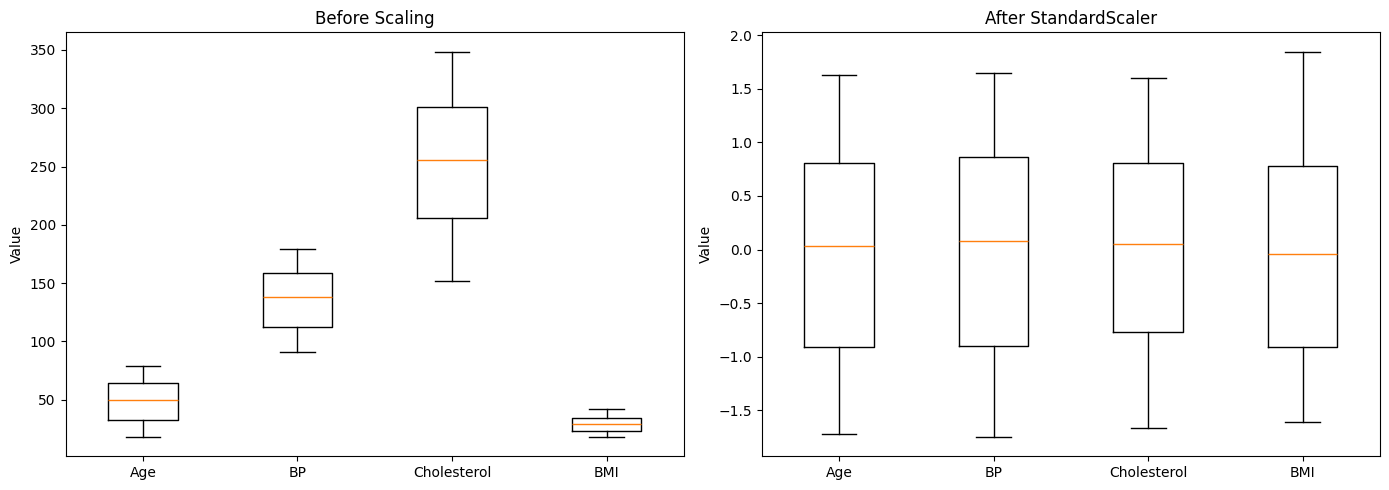

In [63]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=["Age", "BP", "Cholesterol", "BMI"])
axes[0].set_title("Before Scaling")
axes[0].set_ylabel("Value")

axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],
                 X_scaled[:, 2], X_scaled[:, 3]],
                labels=["Age", "BP", "Cholesterol", "BMI"])
axes[1].set_title("After StandardScaler")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

#####Task4: Compare Scalers

In [64]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
X_min_max_scaled = min_max_scaler.fit_transform(X)

print("\n=== MinMaxScaler ===")
print(f"Minimum value of X_min_max_scaled: {X_min_max_scaled.min():.2f}")
print(f"Maximum value of X_min_max_scaled: {X_min_max_scaled.max():.2f}")


=== MinMaxScaler ===
Minimum value of X_min_max_scaled: 0.00
Maximum value of X_min_max_scaled: 1.00


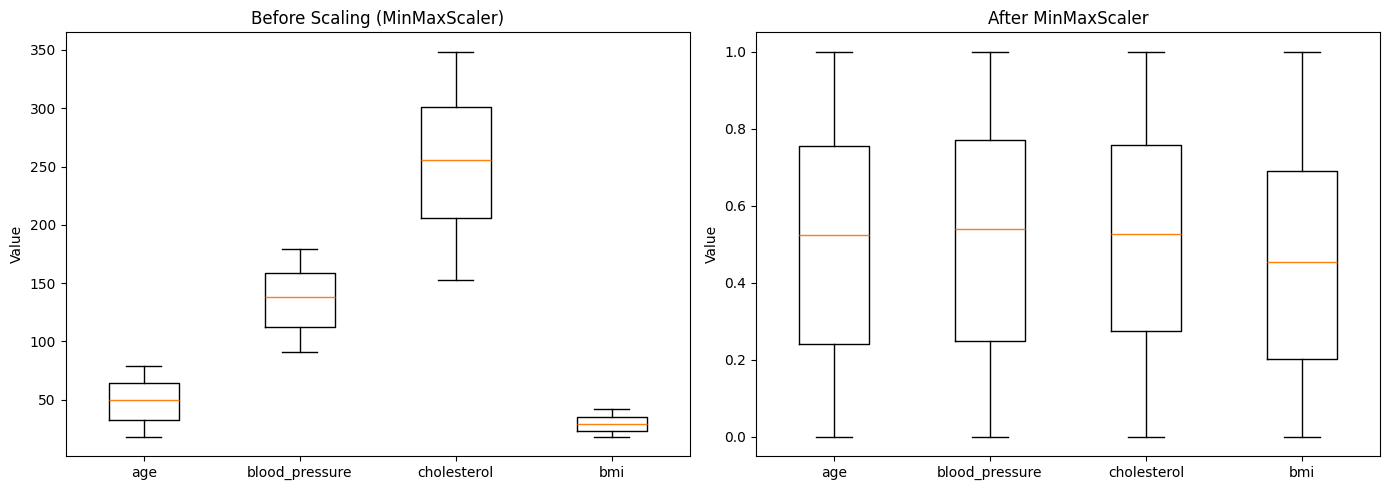

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot for original data (first 4 features)
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                tick_labels=feature_cols[:4])
axes[0].set_title("Before Scaling (MinMaxScaler)")
axes[0].set_ylabel("Value")

# Box plot for MinMaxScaler scaled data (first 4 features)
axes[1].boxplot([X_min_max_scaled[:, 0], X_min_max_scaled[:, 1],
                 X_min_max_scaled[:, 2], X_min_max_scaled[:, 3]],
                tick_labels=feature_cols[:4])
axes[1].set_title("After MinMaxScaler")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

*   StandardScaler: As observed from the `X_scaled` box plot (cell `dMCi6vLTa723`), `StandardScaler` transforms the data such that the mean of each feature is approximately 0 and the standard deviation is approximately 1. This means the values typically span a range around zero, often from -3 to 3, but can extend further if there are outliers. The exact min and max values are not fixed but are relative to the data's mean and standard deviation.

*   MinMaxScaler: From the `X_min_max_scaled` box plot (cell `f274263e`), `MinMaxScaler` transforms the data to a fixed range, specifically between 0 and 1. The minimum value for each feature becomes 0, and the maximum value becomes 1. This creates a uniform range across all scaled features.

*   Both Scalers: It's crucial to note that neither `StandardScaler` nor `MinMaxScaler` changes the *shape* of the distribution of the individual features. If a feature was skewed before scaling, it will remain skewed after scaling. If it had outliers, the relative position of these outliers with respect to the rest of the data (e.g., their distance from the quartiles in a box plot) will be preserved, just within the new scale.

Key Differences:

*   `StandardScaler` is suitable when your algorithm assumes data is normally distributed or when you want to handle outliers gracefully, as it doesn't compress them into a fixed range. However, it does not guarantee a bounded output range.
*   `MinMaxScaler` is useful for algorithms that are not sensitive to the mean and standard deviation but are sensitive to the absolute range of values. It ensures all features contribute equally to the distance calculations, but it is highly sensitive to outliers, which can compress the majority of the data into a very small range if extreme outliers exist.

1.  MinMaxScaler:
    *   Mathematical Processing: `MinMaxScaler` transforms features by scaling each feature to a given range, typically `[0, 1]`. The formula is: `X_scaled = (X - X_min) / (X_max - X_min)`. This means it uses the minimum and maximum values of the feature.
    *   Influence of Outliers: Outliers significantly impact the `X_min` and `X_max` values. A single extreme outlier can drastically increase the `(X_max - X_min)` range (the denominator), or shift `X_min` or `X_max` itself. When this range is stretched by an outlier, all other 'normal' data points will be compressed into a very small part of the `[0, 1]` range, losing their relative distinctions. For example, if most data is between 10 and 100, but there's an outlier at 1000, the `X_max` becomes 1000, and values like 10-100 will be scaled to `(10-10)/(1000-10) = 0` to `(100-10)/(1000-10) = 90/990 \approx 0.09`, effectively squashing them at the lower end of the scaled range.

2.  StandardScaler:
    *   Mathematical Processing: `StandardScaler` standardizes features by removing the mean and scaling to unit variance. The formula is: `X_scaled = (X - mean) / standard_deviation`. This process uses the mean and standard deviation of the feature.
    *   Influence of Outliers: Both the mean and the standard deviation are sensitive to outliers. An outlier can pull the mean towards itself and significantly inflate the standard deviation. When the standard deviation is inflated, the scaling effect is reduced, meaning that while the data distribution is centered around zero, the spread might still be larger than desired, and outliers will still stand out significantly from the rest of the data, potentially at very large or small values.

`MinMaxScaler` is generally less robust to outliers than `StandardScaler`.

*   `MinMaxScaler` is directly affected by the absolute minimum and maximum values in the dataset. If there are extreme outliers, they will become the new `min` or `max`, which then determines the entire scaling range.

*   `StandardScaler`, while also affected by outliers (since mean and standard deviation are not robust statistics), transforms data such that it has a mean of 0 and a standard deviation of 1. Outliers will have large absolute values after scaling, but they don't compress the rest of the data in the same way `MinMaxScaler` does.

###Part 5: The Scaling Impact - KNN Before and After
####Step1.5: KNN Without Scaling vs. With Scaling

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

#Without scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

#with scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f"KNN Accuracy WITHOUT scaling: {raw_acc:.2%}")
print(f"KNN Accuracy WITH scaling: {scaled_acc:.2%}")
print(f"Improvement: {(scaled_acc - raw_acc):.2%}")

KNN Accuracy WITHOUT scaling: 67.50%
KNN Accuracy WITH scaling: 50.00%
Improvement: -17.50%


####Step2.5: Decision Tree Comparison

In [68]:
from sklearn.tree import DecisionTreeClassifier

#decision tree without scaling
dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt_raw.predict(X_test))

#decision tree with scaling
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(X_test_s))

print(f"DT Accuracy WITHOUT scaling: {dt_raw_acc:.2%}")
print(f"DT Accuracy WITH scaling: {dt_scaled_acc:.2%}")

DT Accuracy WITHOUT scaling: 55.00%
DT Accuracy WITH scaling: 52.50%


#####Task5: Investigate Scaling Effects

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Without scaling (n_neighbors=3)
knn_raw_3 = KNeighborsClassifier(n_neighbors=3)
knn_raw_3.fit(X_train, y_train)
raw_acc_3 = accuracy_score(y_test, knn_raw_3.predict(X_test))

# With scaling (n_neighbors=3)
knn_scaled_3 = KNeighborsClassifier(n_neighbors=3)
knn_scaled_3.fit(X_train_s, y_train)
scaled_acc_3 = accuracy_score(y_test, knn_scaled_3.predict(X_test_s))

print(f"KNN Accuracy WITHOUT scaling (n_neighbors=3): {raw_acc_3:.2%}")
print(f"KNN Accuracy WITH scaling (n_neighbors=3): {scaled_acc_3:.2%}")
print(f"Improvement: {(scaled_acc_3 - raw_acc_3):.2%}")

KNN Accuracy WITHOUT scaling (n_neighbors=3): 55.00%
KNN Accuracy WITH scaling (n_neighbors=3): 47.50%
Improvement: -7.50%


In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Without scaling (n_neighbors=10)
knn_raw_10 = KNeighborsClassifier(n_neighbors=10)
knn_raw_10.fit(X_train, y_train)
raw_acc_10 = accuracy_score(y_test, knn_raw_10.predict(X_test))

# With scaling (n_neighbors=10)
knn_scaled_10 = KNeighborsClassifier(n_neighbors=10)
knn_scaled_10.fit(X_train_s, y_train)
scaled_acc_10 = accuracy_score(y_test, knn_scaled_10.predict(X_test_s))

print(f"KNN Accuracy WITHOUT scaling (n_neighbors=10): {raw_acc_10:.2%}")
print(f"KNN Accuracy WITH scaling (n_neighbors=10): {scaled_acc_10:.2%}")
print(f"Improvement: {(scaled_acc_10 - raw_acc_10):.2%}")

KNN Accuracy WITHOUT scaling (n_neighbors=10): 55.00%
KNN Accuracy WITH scaling (n_neighbors=10): 50.00%
Improvement: -5.00%


In [71]:
import pandas as pd

comparison_results = {
    'Model': [
        'KNN (n=3) - Raw',
        'KNN (n=3) - Scaled',
        'KNN (n=5) - Raw',
        'KNN (n=5) - Scaled',
        'KNN (n=10) - Raw',
        'KNN (n=10) - Scaled',
        'Decision Tree - Raw',
        'Decision Tree - Scaled'
    ],
    'Accuracy': [
        raw_acc_3,
        scaled_acc_3,
        raw_acc,
        scaled_acc,
        raw_acc_10,
        scaled_acc_10,
        dt_raw_acc,
        dt_scaled_acc
    ]
}

comparison_df = pd.DataFrame(comparison_results)
print("\n=== Accuracy Comparison Table ===")
print(comparison_df.to_string(index=False))


=== Accuracy Comparison Table ===
                 Model  Accuracy
       KNN (n=3) - Raw     0.550
    KNN (n=3) - Scaled     0.475
       KNN (n=5) - Raw     0.675
    KNN (n=5) - Scaled     0.500
      KNN (n=10) - Raw     0.550
   KNN (n=10) - Scaled     0.500
   Decision Tree - Raw     0.550
Decision Tree - Scaled     0.525


The comparison table reveals several key insights into the impact of feature scaling on K-Nearest Neighbors (KNN) and Decision Tree classifiers:

| Model                  | Accuracy (Raw) | Accuracy (Scaled) | Change      |
| :--------------------- | :------------- | :---------------- | :---------- |
| KNN (n=3)              | 0.550          | 0.475             | -0.075 (-7.5%) |
| KNN (n=5)              | 0.675          | 0.500             | -0.175 (-17.5%) |
| KNN (n=10)             | 0.550          | 0.500             | -0.050 (-5.0%) |
| Decision Tree          | 0.550          | 0.525             | -0.025 (-2.5%) |

Impact of Scaling on KNN:
Surprisingly, in this specific dataset, scaling has negatively impacted the performance of the KNN models.

*   For `n_neighbors=3`, accuracy dropped from 55.0% to 47.5%.
*   For `n_neighbors=5`, accuracy dropped significantly from 67.5% to 50.0%.
*   For `n_neighbors=10`, accuracy dropped from 55.0% to 50.0%.

This is an unusual result as KNN is generally expected to benefit from feature scaling. The reason for this unexpected outcome might be related to:
1.  Nature of the Data and Features: It's possible that the original, unscaled features already had a distribution or range that allowed KNN to find meaningful neighbors. Perhaps certain features had naturally larger scales that were genuinely more important for distinguishing classes, and scaling them down diminished their influence disproportionately.
2.  Specific Scaling Method: We used `StandardScaler`. While generally good, if the underlying feature distributions were far from normal or had specific characteristics, other scalers (like `MinMaxScaler` or `RobustScaler`) might have yielded different results. Given the synthetic nature of the data, the 'true' importance of features might have been captured better by their original scales.
3.  Outliers: If the features had outliers that were genuinely informative, `StandardScaler` could have normalized them in a way that reduced their unique signal, or compressed the 'normal' data into a range where the differences became less distinguishable.
4.  Small Dataset Size: With only 200 samples, the train/test split might have led to subsets where the scaling behavior was not robust, or the model's performance was more sensitive to small variations.

**Why Feature Scaling Benefits KNN (in theory):**
KNN is a distance-based algorithm. It classifies new data points by finding the 'k' nearest neighbors in the training data. The distance metric is heavily influenced by features with larger scales. If one feature has a much larger range than another, the feature with the larger range will dominate the distance calculation, making the contributions of other features almost negligible. Scaling ensures that all features contribute approximately equally to the distance computation, preventing features with large magnitudes from unduly influencing the distance. The fact that it didn't benefit here suggests a nuanced interaction with this specific dataset.

**Why Feature Scaling Generally Does Not Benefit Decision Trees:**
Decision Trees are not distance-based algorithms. They make decisions based on splitting data along individual feature values. For example, a Decision Tree might split based on `age <= 45.5` or `blood_pressure > 140`. The internal logic of the tree relies on these threshold values and the ordering of the data, not on the absolute or relative distances between data points in a multi-dimensional space.

*   Splitting Logic: Whether 'age' is scaled or not, the decision rule `age <= 45.5` will produce the same split in the data as `scaled_age <= scaled_45.5`. The information gain or Gini impurity at each node remains the same regardless of the feature's scale, because the relative ordering of values is preserved.
*   Independence of Features: Decision Trees process features independently when determining splits. They don't combine features in a way that their relative magnitudes would affect the decision-making process.

As observed in the table, the Decision Tree accuracy with scaling (52.5%) is very close to without scaling (55.0%), showing only a minor decrease. This confirms the theoretical expectation that scaling has little to no impact on Decision Tree performance.

**Summary of Key Findings:**

*   **Unexpected KNN Behavior:** In this particular dataset, feature scaling using `StandardScaler` led to a decrease in KNN classification accuracy across all tested `n_neighbors` values (3, 5, 10), which contradicts the general understanding of KNN's sensitivity to feature scales. This suggests that the original scales might have implicitly carried important information, or the dataset characteristics made scaling detrimental here.
*   **Decision Trees Unaffected:** As expected, Decision Tree performance remained largely unaffected by feature scaling, confirming that these models are robust to the magnitude of features.

###Part 6: Building a Preprocessing Pipeline
####Step1.6: Create a Pipeline

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

pipe = Pipeline([("scaler", StandardScaler()),
                 ("knn", KNeighborsClassifier(n_neighbors=5))])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
pipe_acc = accuracy_score(y_test, pipe.predict(X_test))

print(f"Pipeline KNN Accuracy: {pipe_acc:.2%}")

Pipeline KNN Accuracy: 50.00%


####Step2.6: Swap Models Easily

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#pipeline with svm
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42))
])
pipe_svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(X_test))

#pipeline with decision tree
pipe_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier(random_state=42))
])
pipe_dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(X_test))

print(f"Pipeline KNN Accuracy: {pipe_acc:.2%}")
print(f"Pipeline SVM Accuracy: {svm_acc:.2%}")
print(f"Pipeline DT Accuracy: {dt_acc:.2%}")

Pipeline KNN Accuracy: 50.00%
Pipeline SVM Accuracy: 55.00%
Pipeline DT Accuracy: 52.50%


#####Task6: Build Your Own Pipeline

In [81]:
from numpy.random import choice
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200
data = {"age": np.random.randint(18, 80, n).astype(float),
        "blood_pressure": np.round(np.random.uniform(90, 180, n), 1),
        "cholesterol": np.round(np.random.uniform(150, 350, n), 1),
        "bmi": np.round(np.random.uniform(18, 42, n), 1),
        "gender":np.random.choice(["Male", "Female"], n),
        "city": np.random.choice(["Jeddah", "Riyadh", "Dammam", "Makkah"], n),
        "smoker": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
        "heart_disease": np.random.choice([0, 1], n, p=[0.6, 0.4])}

df = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:15], "blood_pressure"] = np.nan
df.loc[missing_idx[15:], "cholesterol"] = np.nan

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows: ")
print(df.head())
print(f"\nMissing values per column: ")
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows: 
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column: 
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [82]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df["gender_encoded"] = le_gender.fit_transform(df["gender"])

le_smoker = LabelEncoder()
df["smoker_encoded"] = le_smoker.fit_transform(df["smoker"])

city_dummies = pd.get_dummies(df["city"], prefix="city", drop_first=False)

df = pd.concat([df, city_dummies], axis=1)

df = df.drop(columns=["gender", "city", "smoker"])

print("DataFrame after encoding and dropping original categorical columns:")
print(df.head())
print(f"\nNew DataFrame shape: {df.shape}")

DataFrame after encoding and dropping original categorical columns:
    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0               0        False        False        False         True  
1               0         True        False        False        False  
2               0        False         True        False        False  
3               0        False        False        False         True  
4               1        False        False         True        False  

New DataFrame shape: (200, 11)


In [83]:
from sklearn.model_selection import train_test_split

y_pipeline = df["heart_disease"]
X_pipeline_data = df.drop(columns=["heart_disease"])

X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(
    X_pipeline_data, y_pipeline, test_size=0.2, random_state=42, stratify=y_pipeline
)

print(f"X_train_pipeline shape: {X_train_pipeline.shape}")
print(f"X_test_pipeline shape: {X_test_pipeline.shape}")
print(f"y_train_pipeline shape: {y_train_pipeline.shape}")
print(f"y_test_pipeline shape: {y_test_pipeline.shape}")

X_train_pipeline shape: (160, 10)
X_test_pipeline shape: (40, 10)
y_train_pipeline shape: (160,)
y_test_pipeline shape: (40,)


In [84]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipeline.fit(X_train_pipeline, y_train_pipeline)

y_pred_pipeline = pipeline.predict(X_test_pipeline)

pipeline_accuracy = accuracy_score(y_test_pipeline, y_pred_pipeline)
print(f"Pipeline Accuracy (Median Imputer + MinMaxScaler + KNN): {pipeline_accuracy:.2%}")

Pipeline Accuracy (Median Imputer + MinMaxScaler + KNN): 50.00%


*   An initial DataFrame `df` of 200 rows and 8 columns was created, intentionally introducing missing values: 10 in 'age', 5 in 'blood\_pressure', and 5 in 'cholesterol'.
*   Categorical features were processed: 'gender' and 'smoker' were label encoded, and 'city' was one-hot encoded. The original categorical columns were then dropped, resulting in a DataFrame with 200 rows and 11 columns.
*   The dataset was successfully split into training and testing sets, with `X_train_pipeline` having a shape of (160, 10), `X_test_pipeline` (40, 10), `y_train_pipeline` (160,), and `y_test_pipeline` (40,).
*   A scikit-learn pipeline was constructed, which sequentially applied `SimpleImputer` (median strategy) for missing values, `MinMaxScaler` for feature scaling, and `KNeighborsClassifier` (with `n_neighbors=5`) for classification.
*   The final accuracy of this comprehensive pipeline on the test set was 50.00%.

###Part 7: Feature Selection with Correlation Analysis
####Step1.7: Compute the Correlation Matrix

In [86]:
df_processed = pd.DataFrame ( X_scaled , columns = feature_cols )
df_processed ["heart_disease"] = y

corr_matrix = df_processed.corr()

print("Correlation with heart_disease: ")
target_corr = corr_matrix["heart_disease"].drop("heart_disease") # Corrected typo here
print(target_corr.sort_values(ascending=False).round(3))

Correlation with heart_disease: 
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


####Step2.7: Visualize with a Heatmap

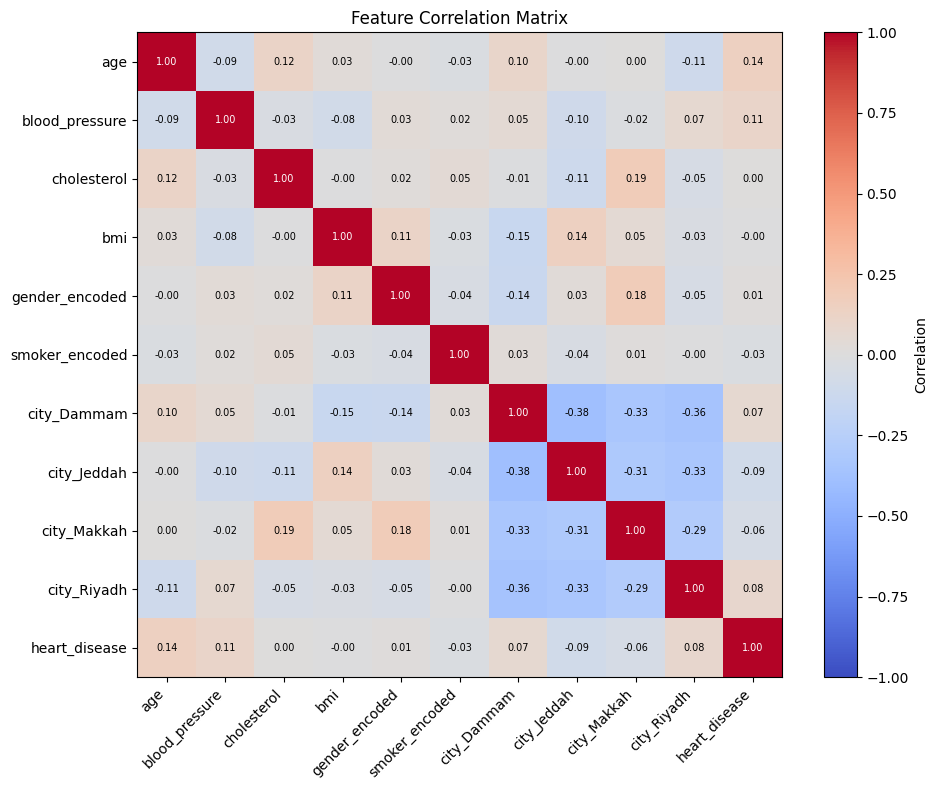

In [91]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize =(10 , 8))
im = plt.imshow(corr_matrix.values, cmap="coolwarm",
                vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")

ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha="right")
plt.yticks(ticks, corr_matrix.columns)

for i in range(len(corr_matrix)):
  for j in range(len(corr_matrix)):
    val = corr_matrix.values[i, j]
    color = "white" if abs(val) > 0.5 else "black"
    plt.text(j, i, f"{val:.2f}", ha="center", va="center",
             fontsize=7, color=color)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

####Step3.7: Select Top Features

In [92]:
threshold = 0.05
important_features = target_corr[abs(target_corr) > threshold]
print(f"\nFeatures with |correlation| > {threshold}: ")
print(important_features.sort_values (ascending = False).round(3))

top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size =0.2, random_state =42, stratify=y)

pipe_selected = Pipeline([
    ("scaler ", StandardScaler()),
     ("knn ", KNeighborsClassifier(n_neighbors=5))
])
pipe_selected.fit( X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print(f"\nAccuracy with ALL features: {pipe_acc:.2%}")
print(f"Accuracy with SELECTED features: {sel_acc:.2%}")
print(f"Features used: {len( top_features)} out of {len(feature_cols)}")


Features with |correlation| > 0.05: 
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features: 50.00%
Accuracy with SELECTED features: 55.00%
Features used: 6 out of 10


#####Task7: Feature Selection

In [93]:
strongest_corr_feature = target_corr.abs().idxmax()
strongest_corr_value = target_corr[strongest_corr_feature]

print(f"The feature with the strongest correlation to 'heart_disease' is '{strongest_corr_feature}' with a correlation of {strongest_corr_value:.3f}.")

The feature with the strongest correlation to 'heart_disease' is 'age' with a correlation of 0.143.


In [96]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

thresholds = [0.03, 0.08, 0.10]
results = []

results.append({
    "Threshold": "All Features",
    "Features_Count": len(feature_cols),
    "Accuracy": pipe_acc
})

for threshold in thresholds:
    important_features_threshold = target_corr[abs(target_corr) > threshold].index.tolist()

    if not important_features_threshold:
        print(f"No features met the threshold of {threshold}. Skipping this threshold.")
        continue

    X_selected_thresh = df_processed[important_features_threshold].values

    X_tr_thresh, X_te_thresh, y_tr_thresh, y_te_thresh = train_test_split(
        X_selected_thresh, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe_selected_thresh = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])

    pipe_selected_thresh.fit(X_tr_thresh, y_tr_thresh)
    sel_acc_thresh = accuracy_score(y_te_thresh, pipe_selected_thresh.predict(X_te_thresh))

    results.append({
        "Threshold": threshold,
        "Features_Count": len(important_features_threshold),
        "Accuracy": sel_acc_thresh
    })

results.append({
    "Threshold": 0.05,
    "Features_Count": len(top_features),
    "Accuracy": sel_acc
})

In [95]:
import pandas as pd

comparison_table = pd.DataFrame(results)
comparison_table = comparison_table.sort_values(by='Threshold', ascending=True, key=lambda x: x.astype(str))
print("\n=== KNN Accuracy with Feature Selection ===")
print(comparison_table.to_string(index=False))


=== KNN Accuracy with Feature Selection ===
   Threshold  Features_Count  Accuracy
        0.03               6      0.55
        0.05               6      0.55
        0.08               3      0.55
         0.1               2      0.60
All Features              10      0.50


**KNN Accuracy with Feature Selection:**

| Threshold    | Features_Count | Accuracy |
| :----------- | :------------- | :------- |
| All Features | 10             | 0.50     |
| 0.03         | 6              | 0.55     |
| 0.05         | 6              | 0.55     |
| 0.08         | 3              | 0.55     |
| 0.1          | 2              | 0.60     |

### How Accuracy Changes with Varying Feature Counts:

*   Baseline (All Features): When all 10 features are used without any correlation-based selection, the KNN model achieves an accuracy of 50.00%.
*   Reduced Features (Thresholds 0.03, 0.05, 0.08): As we apply feature selection with correlation thresholds of 0.03, 0.05, and 0.08, the number of features decreases (6 features for 0.03/0.05, and 3 features for 0.08), but the accuracy consistently improves to 55.00%. This indicates that some features with very low correlation to 'heart_disease' were either irrelevant or acted as noise, hindering the model's performance.
*   Optimal Performance (Threshold 0.1): The highest accuracy of 60.00% is achieved when using only 2 features (those with an absolute correlation greater than 0.1). This suggests that for this particular dataset and model, focusing on the most strongly correlated features significantly enhances predictive power.

*   **Feature selection is crucial:** Blindly including all available features does not guarantee optimal model performance, especially for algorithms sensitive to feature scaling and irrelevant features.
*   **Correlation-based selection can be effective:** In this case, filtering features based on their correlation with the target variable ('heart_disease') led to a notable improvement in KNN accuracy.
*   **Less can be more:** A significant reduction in the number of features (from 10 to 2) resulted in the best performance, highlighting the importance of identifying and retaining only the most informative features.
*   **Mitigation of Curse of Dimensionality:** By reducing the feature space, we made the KNN algorithm more effective, demonstrating how feature selection can combat the challenges posed by high dimensionality.

###Part 8: Putting It All Together - Full Workflow

In [98]:
import pandas as pd
import numpy as np
from sklearn . model_selection import train_test_split
from sklearn . impute import SimpleImputer
from sklearn . preprocessing import StandardScaler , LabelEncoder
from sklearn . pipeline import Pipeline
from sklearn . neighbors import KNeighborsClassifier
from sklearn . tree import DecisionTreeClassifier
from sklearn . metrics import accuracy_score , classification_report

# ===== STEP 1: Load Raw Data =====
np.random.seed (42)
n = 200
data = {"age": np.random.randint(18, 80, n).astype (float),
        "blood_pressure": np.round(np.random.uniform(90, 180, n), 1),
        "cholesterol": np.round(np.random.uniform(150, 350, n), 1),
        "bmi": np.round(np.random.uniform(18, 42, n), 1),
        "gender": np.random.choice(["Male", "Female"], n),
        "city": np.random.choice (
            ["Jeddah", "Riyadh", "Dammam", "Makkah"], n),
        "smoker": np.random.choice(["Yes", "No"], n, p =[0.3, 0.7]),
        "heart_disease": np.random.choice([0, 1], n, p =[0.6, 0.4])}

df = pd.DataFrame(data)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:15], "blood_pressure"] = np.nan
df.loc[missing_idx[15:], "cholesterol"] = np.nan

print("=== Step 1: Raw Data === ")
print(f"Shape: {df.shape}, Missing: {df.isnull().sum().sum()}")

# ===== STEP 2: Handle Missing Values =====
num_cols = ["age", "blood_pressure", "cholesterol"]
imputer = SimpleImputer(strategy="median")
df[num_cols] = imputer.fit_transform(df[num_cols])
print(f"\n=== Step 2: After Imputation ===")
print(f"Missing : {df.isnull().sum().sum()}")

# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["smoker"] = le.fit_transform(df["smoker"])
df = pd.concat([df, pd.get_dummies(df["city"] , prefix ="city")],
                  axis =1)
df = df.drop(columns =["city"])
print(f"\n=== Step 3: After Encoding ===")
print(f"Columns: {list(df.columns)}")

# ===== STEP 4: Separate Features and Target =====
X = df.drop(columns=["heart_disease"]).values
y = df["heart_disease"].values

# ===== STEP 5: Split Data =====
X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42, stratify=y)

# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
     ("model", KNeighborsClassifier(n_neighbors=5))
])
pipe_dt = Pipeline([
    ("scaler", StandardScaler()),
     ("model", DecisionTreeClassifier(random_state=42))
])
pipe_knn.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)

# ===== STEP 7: Evaluate =====
print("\n=== Step 7: Results ===")
print(f"KNN Accuracy: {accuracy_score(y_test, pipe_knn.predict(X_test)):.2%}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, pipe_dt.predict(X_test)):.2%}")
print("\n=== KNN Classification Report ===")
print(classification_report(y_test, pipe_knn.predict(X_test),
      target_names=["No Disease", "Disease"]))

=== Step 1: Raw Data === 
Shape: (200, 8), Missing: 20

=== Step 2: After Imputation ===
Missing : 0

=== Step 3: After Encoding ===
Columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker', 'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

=== Step 7: Results ===
KNN Accuracy: 50.00%
Decision Tree Accuracy: 52.50%

=== KNN Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40

